<a href="https://colab.research.google.com/github/wiktorstudia/PUM_projekt/blob/main/Preprocessing_Seul_bike.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocesing Seul Bike Data

In [36]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import os

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/SeoulBikeData.csv', encoding='unicode_escape')

print(df.info())
print(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        8760 non-null   object 
 1   Rented Bike Count           8760 non-null   int64  
 2   Hour                        8756 non-null   float64
 3   Temperature(Â°C)            8760 non-null   float64
 4   Humidity(%)                 8760 non-null   int64  
 5   Wind speed (m/s)            8760 non-null   float64
 6   Visibility (10m)            8760 non-null   int64  
 7   Dew point temperature(Â°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)     8760 non-null   float64
 9   Rainfall(mm)                8760 non-null   float64
 10  Snowfall (cm)               8760 non-null   float64
 11  Seasons           

In [37]:
#zamiana kolumny data
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek # 0=Poniedziałek, 6=Niedziela
#df = df.drop('Date', axis=1) # Oryginalna data nie jest już potrzebna
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

# 3. Uzupełniamy tylko te wiersze, gdzie w kolumnie 'Seasons' jest NaN (brak)
df.loc[df['Seasons'].isna(), 'Seasons'] = df[df['Seasons'].isna()]['Date'].map(get_season)

df['Hour'] = df['Hour'].fillna(df['Hour'].mode()[0])
print(f"Pozostałe braki w Seasons: {df['Seasons'].isna().sum()}")
print(df.info())

Pozostałe braki w Seasons: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        8760 non-null   datetime64[ns]
 1   Rented Bike Count           8760 non-null   int64         
 2   Hour                        8760 non-null   float64       
 3   Temperature(Â°C)            8760 non-null   float64       
 4   Humidity(%)                 8760 non-null   int64         
 5   Wind speed (m/s)            8760 non-null   float64       
 6   Visibility (10m)            8760 non-null   int64         
 7   Dew point temperature(Â°C)  8760 non-null   float64       
 8   Solar Radiation (MJ/m2)     8760 non-null   float64       
 9   Rainfall(mm)                8760 non-null   float64       
 10  Snowfall (cm)               8760 non-null   float64       
 11  Seasons                    

In [38]:
#LabelEncoder
from sklearn.preprocessing import LabelEncoder

col_to_change=['Holiday', 'Functioning Day']
for col in col_to_change:
    print(col)
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# One-Hot Encoding dla kolumny Seasons
# prefix='Season' sprawi, że kolumny będą się nazywać Season_Autumn, Season_Spring itd.
df = pd.get_dummies(df, columns=['Seasons'], prefix='Season')

# Konwersja kolumn True/False na 0/1
season_cols = ['Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter']
for col in season_cols:
    df[col] = df[col].astype(int)

# Usuwanie kolumny Date
df = df.drop('Date', axis=1)

# Sprawdźmy jak wyglądają nowe kolumny
print("Nowe kolumny w zbiorze:")
print(df.columns[-4:]) # Wyświetla 4 ostatnie kolumny
print("\nPierwsze 5 wierszy z nowymi kolumnami:")
print(df[['Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter']].head())

Holiday
Functioning Day
Nowe kolumny w zbiorze:
Index(['Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter'], dtype='object')

Pierwsze 5 wierszy z nowymi kolumnami:
   Season_Autumn  Season_Spring  Season_Summer  Season_Winter
0              0              0              0              1
1              0              0              0              1
2              0              0              0              1
3              0              0              0              1
4              0              0              0              1


In [39]:
print(df.head())
print(df.info())

   Rented Bike Count  Hour  Temperature(Â°C)  Humidity(%)  Wind speed (m/s)  \
0                254   0.0              -5.2           37               2.2   
1                204   1.0              -5.5           38               0.8   
2                173   2.0              -6.0           39               1.0   
3                107   3.0              -6.2           40               0.9   
4                 78   4.0              -6.0           36               2.3   

   Visibility (10m)  Dew point temperature(Â°C)  Solar Radiation (MJ/m2)  \
0              2000                       -17.6                      0.0   
1              2000                       -17.6                      0.0   
2              2000                       -17.7                      0.0   
3              2000                       -17.6                      0.0   
4              2000                       -18.6                      0.0   

   Rainfall(mm)  Snowfall (cm)  Holiday  Functioning Day  Day  Month

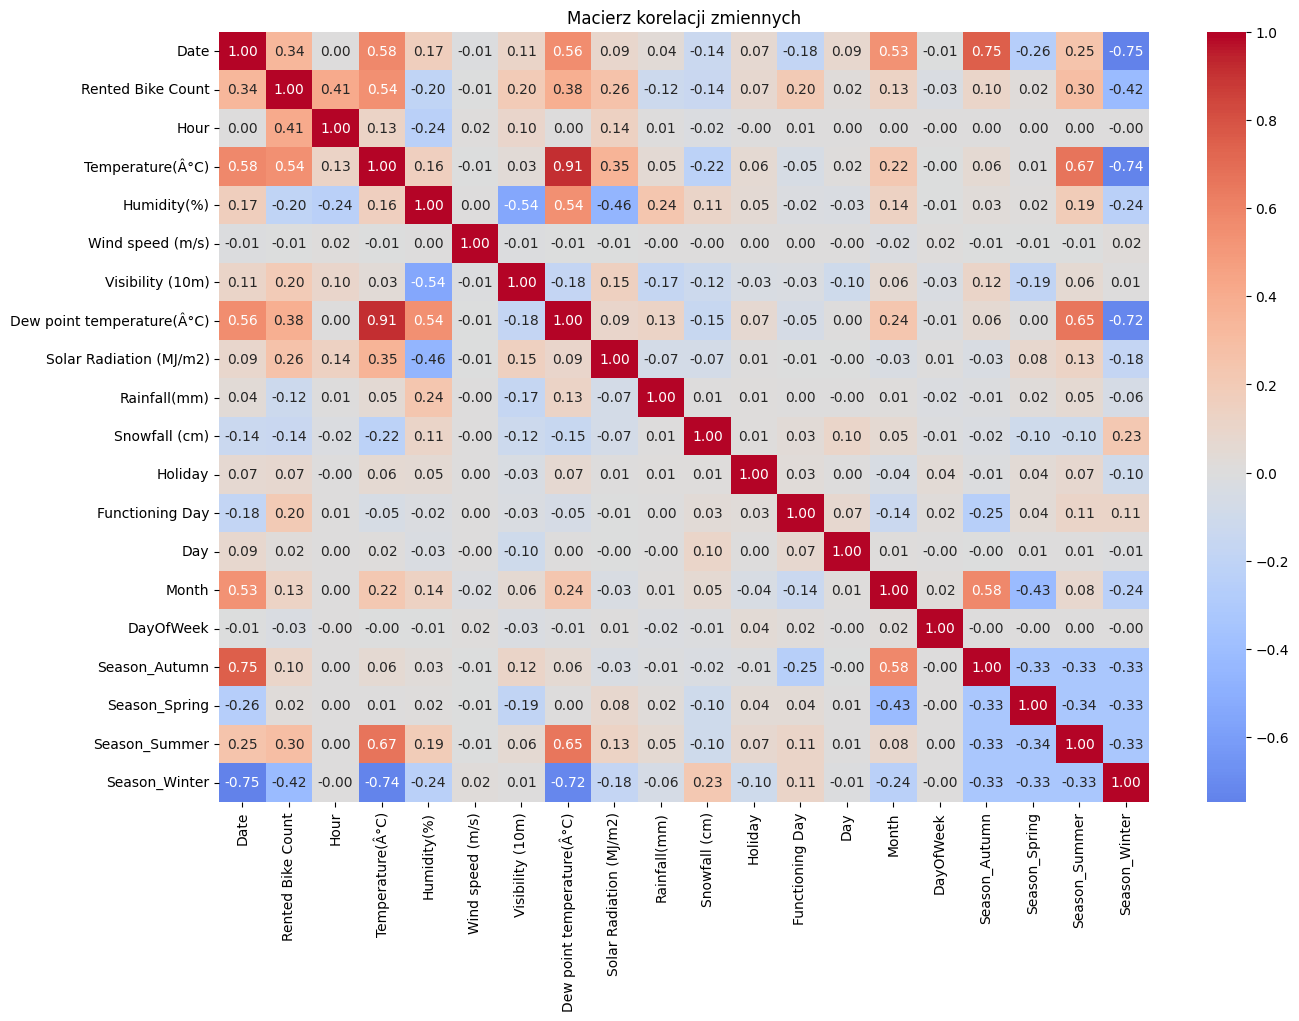

Pary kolumn o korelacji > 0.3:
Temperature(Â°C)            Dew point temperature(Â°C)    0.912798
Season_Autumn               Date                          0.749317
Season_Summer               Temperature(Â°C)              0.665846
Dew point temperature(Â°C)  Season_Summer                 0.652378
Month                       Season_Autumn                 0.580662
Temperature(Â°C)            Date                          0.578034
Date                        Dew point temperature(Â°C)    0.562890
Rented Bike Count           Temperature(Â°C)              0.538558
Humidity(%)                 Dew point temperature(Â°C)    0.536894
Date                        Month                         0.529399
Hour                        Rented Bike Count             0.410841
Rented Bike Count           Dew point temperature(Â°C)    0.379788
Solar Radiation (MJ/m2)     Temperature(Â°C)              0.353505
Date                        Rented Bike Count             0.340772
Season_Winter               Sea

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Rysowanie heatmapy
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Macierz korelacji zmiennych')
plt.show()

# Wyznaczenie par o korelacji wyższej niż 0.3 (wartość bezwzględna)
print("Pary kolumn o korelacji > 0.3:")
corr_pairs = corr_matrix.unstack()
sorted_pairs = corr_pairs.sort_values(kind="quicksort", ascending=False)

# Filtrowanie par (pomijając autokorelację 1.0)
strong_corr = sorted_pairs[(abs(sorted_pairs) > 0.3) & (sorted_pairs < 1.0)]
print(strong_corr.drop_duplicates())

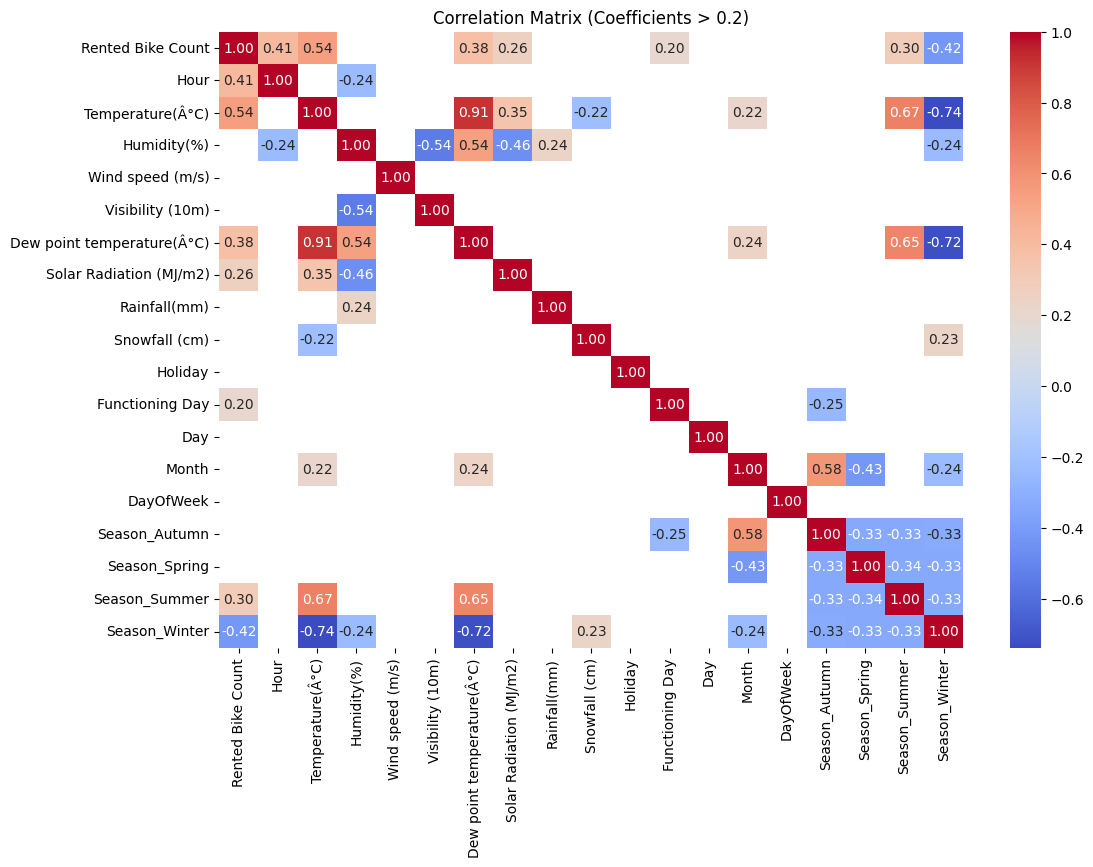

Usuwanie kolumn z korelacją > 90%: ['Dew point temperature(Â°C)']


In [41]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Identify correlations greater than 0.2
corr_matrix = df.corr()
high_corr = corr_matrix[abs(corr_matrix) > 0.2]
plt.figure(figsize=(12, 8))
sns.heatmap(high_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Coefficients > 0.2)')
plt.show()

# 2. Usuwanie kolumn o korelacji > 0.9
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

if to_drop:
    print(f"Usuwanie kolumn z korelacją > 90%: {to_drop}")
    df = df.drop(columns=to_drop)

In [42]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold

numeric_df = df.select_dtypes(include=[np.number])

selector = VarianceThreshold(threshold=0.01)

selector.fit(numeric_df)
mask = selector.get_support()
kept_numeric_cols = numeric_df.columns[mask]

non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

df = df[non_numeric_cols + list(kept_numeric_cols)].copy()

print(f"Kolumny zachowane po VarianceThreshold: {list(kept_numeric_cols)}")
print(f"Usunięte kolumny (niska zmienność): {set(numeric_df.columns) - set(kept_numeric_cols)}")

# Czyszczenie braków danych jeśli istnieją
print("Przed dropna:", df.shape)
df.dropna(inplace=True)
print("Po dropna:", df.shape)

Kolumny zachowane po VarianceThreshold: ['Rented Bike Count', 'Hour', 'Temperature(Â°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Holiday', 'Functioning Day', 'Day', 'Month', 'DayOfWeek', 'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter']
Usunięte kolumny (niska zmienność): set()
Przed dropna: (8760, 18)
Po dropna: (8760, 18)


In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print(f"Liczba cech przed PCA: {X_scaled.shape[1]}")
print(f"Liczba komponentów po PCA (zachowując 90% wariancji): {pca.n_components_}")
print(f"Wyjaśniona wariancja przez poszczególne komponenty: \n{pca.explained_variance_ratio_}")
print(f"Suma wyjaśnionej wariancji: {sum(pca.explained_variance_ratio_):.2f}")

Liczba cech przed PCA: 18
Liczba komponentów po PCA (zachowując 90% wariancji): 12
Wyjaśniona wariancja przez poszczególne komponenty: 
[0.16095621 0.11760837 0.11003745 0.08014412 0.06561992 0.05819853
 0.05692994 0.05508917 0.0536632  0.05273379 0.04851994 0.04510832]
Suma wyjaśnionej wariancji: 0.90


In [44]:
print(df.head())
print(df.info())

   Rented Bike Count  Hour  Temperature(Â°C)  Humidity(%)  Wind speed (m/s)  \
0                254   0.0              -5.2           37               2.2   
1                204   1.0              -5.5           38               0.8   
2                173   2.0              -6.0           39               1.0   
3                107   3.0              -6.2           40               0.9   
4                 78   4.0              -6.0           36               2.3   

   Visibility (10m)  Solar Radiation (MJ/m2)  Rainfall(mm)  Snowfall (cm)  \
0              2000                      0.0           0.0            0.0   
1              2000                      0.0           0.0            0.0   
2              2000                      0.0           0.0            0.0   
3              2000                      0.0           0.0            0.0   
4              2000                      0.0           0.0            0.0   

   Holiday  Functioning Day  Day  Month  DayOfWeek  Season_Aut